In [1]:
%matplotlib inline

In [1]:
organs = "spleen, bladder, gallbladder, esophagus, stomach, duodenum, colon, prostate, uterus".split(", ")

In [2]:
tumor_types = [#'adrenal_gland_lesion', 'adrenal_lesion', 'bone_lesion', 'breast_lesion', 'kidney_lesion', 'liver_lesion', 'lung_lesion', 'pancreatic_lesion', 
       'bladder_lesion', 'colon_lesion', 'duodenum_lesion', 'esophagus_lesion',
       'gallbladder_lesion', 
       'prostate_lesion',
       'spleen_lesion', 'stomach_lesion',
       'uterus_lesion']

In [3]:
import pandas as pd
tumor_sheet = pd.read_csv("../../Data/metadata_per_tumor_ucsf_batch_1_to_6_and_merlin.csv")

/local/rpinise1/3754629/ipykernel_3418535/75800161.py:2: DtypeWarning: Columns (10,12,13,14,16,17,18,19,20,21,22,25,31,32,34,35,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,95,96,97,98,99,100,101,102) have mixed types. Specify dtype option on import or set low_memory=False.
  tumor_sheet = pd.read_csv("../../Data/metadata_per_tumor_ucsf_batch_1_to_6_and_merlin.csv")


In [4]:
stomach_tumors = tumor_sheet[tumor_sheet["Organ"]=="stomach"]

In [13]:
radiomics = pd.read_csv("mask_metrics_pyradiomics.csv")

In [15]:
stomach_tumors = stomach_tumors[stomach_tumors["BDMAP ID"].isin(radiomics["bdmap_id"])]

In [56]:
idx = []
reports = []
ids = []
widths = []
for s in stomach_tumors.iterrows():
    i, row = s
    if("thickening" in row["DNN Answer"].lower() and (radiomics[radiomics["bdmap_id"]==row["BDMAP ID"]]["volume_ml"]<20).all()):
        idx.append(i)
        reports.append(row["DNN Answer"])
        ids.append(row["BDMAP ID"])
        #widths.append(radiomics[radiomics["bdmap_id"]==row["BDMAP ID"]]["diameter_x_mm"].values[0])

In [59]:
radiomics[radiomics["bdmap_id"].isin(ids)]

,bdmap_id,organ,diameter_x_mm,diameter_y_mm,diameter_z_mm,volume_ml,sphericity,surface_volume_ratio,elongation,flatness,max_3d_diameter_mm,num_components
436,BDMAP_00037344,stomach,45.703125,42.890625,5.00,5.135345,0.387836,0.722736,0.789419,0.119400,56.003366,1
461,BDMAP_00037765,stomach,40.175794,23.375008,17.50,8.648578,0.739720,0.318494,0.518387,0.481202,42.456481,1
463,BDMAP_00037846,stomach,9.843750,9.843750,8.75,0.351238,0.786046,0.871972,0.956278,0.911763,10.757356,1
510,BDMAP_00038749,stomach,23.888682,23.888682,27.50,8.509195,0.841869,0.281370,0.787856,0.680455,34.923832,1
558,BDMAP_00039509,stomach,6.328125,7.031250,10.00,0.249767,0.790024,0.971998,0.621579,0.537472,11.917328,1
653,BDMAP_00041672,stomach,9.343744,8.759760,8.75,0.338817,0.772130,0.898405,0.860261,0.663039,12.477306,1
679,BDMAP_00042198,stomach,28.699219,40.734375,27.50,17.893677,0.785975,0.235239,0.807310,0.567418,47.852007,1
735,BDMAP_00043688,stomach,30.656250,24.695312,12.50,4.876239,0.724154,0.393814,0.675233,0.386741,34.142976,1
799,BDMAP_00045957,stomach,15.468750,19.687500,18.75,3.597113,0.842486,0.374631,0.879998,0.697305,25.120923,1
1023,BDMAP_00058264,stomach,43.046903,40.820339,25.00,12.913711,0.632484,0.325900,0.551487,0.389587,55.970815,1


(array([6., 1., 6., 7., 2., 6., 6., 3., 4., 4., 2., 1., 1., 2., 3., 2., 0.,
        2., 0., 0., 3., 3., 3., 4., 3., 2., 2., 2., 0., 2., 0., 2., 1., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([  6.328125,  10.69875 ,  15.069375,  19.44    ,  23.810625,
         28.18125 ,  32.551875,  36.9225  ,  41.293125,  45.66375 ,
         50.034375,  54.405   ,  58.775625,  63.14625 ,  67.516875,
         71.8875  ,  76.258125,  80.62875 ,  84.999375,  89.37    ,
         93.740625,  98.11125 , 102.481875, 106.8525  , 111.223125,
        115.59375 , 119.964375, 124.335   , 128.705625, 133.07625 ,
        137.446875, 141.8175  , 146.188125, 150.55875 , 154.929375,
        159.3     , 163.670625, 168.04125 , 172.411875, 176.7825  ,
        181.153125, 185.52375 , 189.894375, 194.265   , 198.635625,
        203.00625 , 207.376875, 211.7475  , 216.118125, 220.48875 ,
        224.859375]),
 <BarContainer object of 50 artists>)

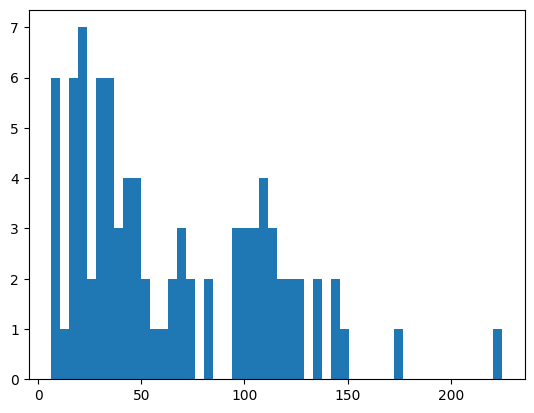

In [48]:
from matplotlib import pyplot as plt
import numpy as np
plt.hist(widths,bins=50)

In [31]:
radiomics[radiomics["bdmap_id"]=="BDMAP_00058264"].to_csv("StomachInfiltrativeData.csv",index=False)

In [35]:
idx

[55289,
 55290,
 88312,
 88364,
 88365,
 88436,
 88579,
 88861,
 98753,
 112785,
 113497,
 114967,
 116896,
 116897,
 126561,
 128706,
 131210,
 142371,
 142372,
 184387,
 269454,
 301178,
 303522,
 304899,
 305303,
 307689,
 308175,
 312849,
 315535,
 315787,
 319338,
 320257,
 320832,
 321490,
 323673,
 323733,
 325244,
 326272,
 328965,
 329269,
 330897,
 333439,
 336596,
 337010,
 338030,
 339859,
 341236,
 342119,
 343106,
 343477,
 344688,
 344788,
 344964,
 345081,
 346764,
 347119,
 347178,
 348628,
 350578,
 350817,
 350818,
 351276,
 351759,
 351760,
 352979,
 353063,
 353546,
 353580,
 353926,
 354479,
 355705,
 355838,
 356351,
 357229,
 358034,
 359782,
 361133,
 362370,
 362471,
 364818,
 365250,
 366465,
 367440,
 371007,
 371098,
 372528,
 373210]

In [1]:
from monai.transforms.io.array import LoadImage, SaveImage
from monai.data.image_reader import ImageReader
import numpy as np

def load_mask(bdmap_id, organ):
    loader = LoadImage(image_only=False, dtype=np.float32)
    mask, meta = loader("/projects/bodymaps/Data/radiologist_annotations_merlin_ucsf_atlas_multi_cancer/" + bdmap_id + "/segmentations/" + organ + "_lesion.nii.gz")
    spacing = meta["pixdim"][1:4]  # (sx, sy, sz) in mm
    return mask, spacing

In [ ]:
from scipy.stats import skew

def compute_diameters(mask: np.ndarray, voxel_spacing=(1.0, 1.0, 1.0)):
    if mask.ndim == 4:
        mask = mask.squeeze(0)
    
    zeros = {"diameter_x_mm": 0, "diameter_y_mm": 0, "diameter_z_mm": 0,
             "mean_x_mm": 0, "mean_y_mm": 0, "mean_z_mm": 0,
             "std_x_mm": 0, "std_y_mm": 0, "std_z_mm": 0,
             "skew_x": 0, "skew_y": 0, "skew_z": 0}
    if not mask.any():
        return zeros

    def span(axis):
        projected = np.any(mask, axis=axis)
        nonzero_idx = np.where(projected)[0]
        return nonzero_idx[-1] - nonzero_idx[0] + 1

    dx = span(axis=(1, 2))
    dy = span(axis=(0, 2))
    dz = span(axis=(0, 1))
    diameters_mm = np.array([dx, dy, dz]) * np.array(voxel_spacing)

    coords = np.argwhere(mask > 0)        # (N, 3)
    coords_mm = coords * np.array(voxel_spacing)
    means_mm = coords_mm.mean(axis=0)
    stds_mm  = coords_mm.std(axis=0)
    skews    = skew(coords_mm, axis=0)    # (3,) — one per dimension

    return {
        "diameter_x_mm": float(diameters_mm[0]),
        "diameter_y_mm": float(diameters_mm[1]),
        "diameter_z_mm": float(diameters_mm[2]),
        "mean_x_mm":     float(means_mm[0]),
        "mean_y_mm":     float(means_mm[1]),
        "mean_z_mm":     float(means_mm[2]),
        "std_x_mm":      float(stds_mm[0]),
        "std_y_mm":      float(stds_mm[1]),
        "std_z_mm":      float(stds_mm[2]),
        "skew_x":        float(skews[0]),
        "skew_y":        float(skews[1]),
        "skew_z":        float(skews[2]),
    }
def compute_mask_metrics(mask, voxel_spacign):
    sx, sy, sz = voxel_spacign
    voxel_vol_ml = sx * sy * sz / 1000

    diameters = compute_diameters(mask, voxel_spacign)
    volume_ml = float(mask.sum() * voxel_vol_ml)
    return [*diameters.values(), volume_ml]
from tqdm import tqdm
def generate_mask_diffusion_txt(segmentation_paths,per_tumor_df):
    mask_diffusion_txt = []
    for segmentation_path in tqdm(segmentation_paths):
        bdmap = segmentation_path.split("/")[-3]
        organ = " ".join(segmentation_path.split("/")[-1].split("_")[:-1])
        try:
            mask, voxel_spacign = load_mask(bdmap, organ)
        except Exception as e:
            print(e)
            print(bdmap)
        metrics = compute_mask_metrics(mask, voxel_spacign)
        new_row = [bdmap, organ, *metrics]
        mask_diffusion_txt.append(new_row)
    return mask_diffusion_txt
            
import glob
bdmaps_with_tumor_mask = glob.glob("/projects/bodymaps/Data/radiologist_annotations_merlin_ucsf_atlas_multi_cancer/*/segmentations/*")
generate_mask_diffusion_txt(bdmaps_with_tumor_mask, tumor_sheet)

In [ ]:
generate_mask_diffusion_txt

In [ ]:
tumor_sheet.dropna(axis=1, how="all", inplace=True)

In [ ]:
filtered_df = tumor_sheet[(tumor_sheet["BDMAP ID"].isin(subject_data.subject) & tumor_sheet["Organ"].isin(organs))]

In [ ]:
tumor_sheet

,Unnamed: 0,Encrypted Accession Number,Tumor ID,Organ,Tumor Type,Tumor Location,Tumor Size (mm),Tumor Attenuation,Type Certainty,DNN Answer,...,no_lesion_ever,no_malignant_lesion_ever,longitudinal_prediagnostic_for_lesion,longitudinal_prediagnostic_for_malignant,longitudinal_prediagnostic_for_benign,longitudinal_prediagnostic_for_primary,longitudinal_prediagnostic_3_years_for_lesion,longitudinal_prediagnostic_3_years_for_malignant,longitudinal_prediagnostic_3_years_for_benign,longitudinal_prediagnostic_3_years_for_primary
0,0.0,kAATlBIJxHN,no lesion,no lesion,no lesion,no lesion,U,no lesion,no lesion,No lesions mentioned.\n\nJustification:\n\nHis...,...,no,no,[],[],[],[],[],[],[],[]
1,1.0,XAZx1WV,no lesion,no lesion,no lesion,no lesion,U,no lesion,no lesion,No lesions mentioned.\n\nJustification:\n\nHis...,...,no,no,['pancreas'],['pancreas'],[],[],['pancreas'],['pancreas'],[],[]
2,2.0,khIJAkPD,no lesion,no lesion,no lesion,no lesion,U,no lesion,no lesion,No lesions mentioned.\n\nJustification:\n\nHis...,...,no,no,[],[],[],[],[],[],[],[]
3,3.0,kIAT5NgNUxM,no lesion,no lesion,no lesion,no lesion,U,no lesion,no lesion,No lesions mentioned.\n\nJustification:\n\nHis...,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,3bTgbfhH,tumor 1,kidney,cyst,bilateral,U,u,certain,Answer (template filled):\n\nlesion 1: type = ...,...,no,no,[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474268,NaN,zdXloBh,tumor 1,uterus,leiomyoma,right lateral aspect of the uterine body,40.0,u,certain,\n\nlesion 1: type = Leiomyoma; certainty = ce...,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
474269,NaN,zmMBDAt,no lesion,no lesion,no lesion,no lesion,U,no lesion,no lesion,\n\nNo lesions mentioned.\n\nJustification: \...,...,no,no,[],[],[],[],[],[],[],[]
474270,NaN,zy47dhZ,no lesion,no lesion,no lesion,no lesion,U,no lesion,no lesion,\n\nNo lesions mentioned.\n\nJustification: \...,...,no,no,['pelvis'],['pelvis'],[],[],[],[],[],[]
474271,NaN,zy47dhZ,no lesion,no lesion,no lesion,no lesion,U,no lesion,no lesion,\n\nNo lesions mentioned.\n\nJustification: \...,...,no,no,['pelvis'],['pelvis'],[],[],[],[],[],[]


In [ ]:
tumor_data = {
    "subject": [],
    "image_path": [],
    "tumor_mask_path": [],
    "tumor_type": []
}

# add all filtered_df columns
for c in filtered_df.columns:
    tumor_data[c] = []

for _, row in subject_data.iterrows():

    bdmap_id = row["subject"]

    for tumor_type in tumor_types:

        if pd.notna(row[tumor_type]):

            tumor_data["subject"].append(bdmap_id)
            tumor_data["image_path"].append(row["image"])
            tumor_data["tumor_mask_path"].append(row[tumor_type])
            tumor_data["tumor_type"].append(tumor_type)

            # match in filtered_df
            match = filtered_df[
                (filtered_df["BDMAP ID"] == bdmap_id) &
                (filtered_df["Organ"] == tumor_type.split("_")[0])
            ]

            if len(match) > 0:
                match_row = match.iloc[0]

                for c in filtered_df.columns:
                    tumor_data[c].append(match_row[c])

            else:
                for c in filtered_df.columns:
                    tumor_data[c].append(pd.NA)
                print(bdmap_id)

tumor_data_df = pd.DataFrame(tumor_data)

BDMAP_00376086
BDMAP_00014574
BDMAP_00376511
BDMAP_00376114
BDMAP_00014502
BDMAP_00376754
BDMAP_00014587
BDMAP_00014597
BDMAP_00014512
BDMAP_00376767
BDMAP_00022465
BDMAP_00184281
BDMAP_00014492
BDMAP_00014637
BDMAP_00376464
BDMAP_00002223
BDMAP_00014539
BDMAP_00022466
BDMAP_00376189
BDMAP_00376314
BDMAP_00376309
BDMAP_00014612
BDMAP_00377079
BDMAP_00001535
BDMAP_00014603
BDMAP_00376011
BDMAP_00376980
BDMAP_00000717
BDMAP_00161572
BDMAP_00014580
BDMAP_00014633
BDMAP_00022470
BDMAP_00061064
BDMAP_00014588
BDMAP_00014515
BDMAP_00014594
BDMAP_00014614
BDMAP_00014595
BDMAP_00000096
BDMAP_00014585
BDMAP_00022434
BDMAP_00014600
BDMAP_00033722
BDMAP_00375929
BDMAP_00001600
BDMAP_00014508
BDMAP_00061152
BDMAP_00376289
BDMAP_00061219
BDMAP_00022455
BDMAP_00001968
BDMAP_00375848
BDMAP_00375848
BDMAP_00376008
BDMAP_00376693
BDMAP_00014542
BDMAP_00004132
BDMAP_00014596
BDMAP_00014540
BDMAP_00022463
BDMAP_00376552
BDMAP_00376005
BDMAP_00022478
BDMAP_00002727
BDMAP_00014531
BDMAP_00003552
BDMAP_0002

In [ ]:
tumor_data_df

,subject,image_path,tumor_mask_path,tumor_type,Unnamed: 0,Encrypted Accession Number,Tumor ID,Organ,Tumor Type,Tumor Location,...,no_lesion_ever,no_malignant_lesion_ever,longitudinal_prediagnostic_for_lesion,longitudinal_prediagnostic_for_malignant,longitudinal_prediagnostic_for_benign,longitudinal_prediagnostic_for_primary,longitudinal_prediagnostic_3_years_for_lesion,longitudinal_prediagnostic_3_years_for_malignant,longitudinal_prediagnostic_3_years_for_benign,longitudinal_prediagnostic_3_years_for_primary
0,BDMAP_00167843,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,stomach_lesion,347119.0,AC423ce9c,tumor 3,stomach,gastric adenocarcinoma,antrum/pylorus,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BDMAP_00184807,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,stomach_lesion,374824.0,AC42454c0,tumor 3,stomach,mass,lesser curvature,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BDMAP_00376086,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,esophagus_lesion,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,BDMAP_00184175,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,stomach_lesion,353546.0,AC4244df0,tumor 4,stomach,primary neoplasm,proximal,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BDMAP_00179735,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,bladder_lesion,339084.0,AC4242d84,tumor 6,bladder,malignant,posterior aspect,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,BDMAP_00040598,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,spleen_lesion,145250.0,ceIqCgn6,tumor 1,spleen,metastasis,inferior pole,...,no,no,[],[],[],[],[],[],[],[]
2024,BDMAP_00157636,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,gallbladder_lesion,263042.0,c4iTEOAscpO,tumor 1,gallbladder,gallbladder cancer,u,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025,BDMAP_00033765,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,spleen_lesion,162514.0,BDMAP_00033765,tumor 1,spleen,u,center,...,no,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026,BDMAP_00175163,/projects/bodymaps/Data/image_only/AbdomenAtla...,/projects/bodymaps/Data/radiologist_annotation...,bladder_lesion,374729.0,AC4240990,tumor 5,bladder,tumor,u,...,no,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd

In [ ]:
image_sheet = pd.read_csv("../../Data/metadata_ucsf_batch_1_to_6_and_merlin.csv")

/local/rpinise1/3706686/ipykernel_1152827/4067732454.py:1: DtypeWarning: Columns (108,109,110,112,118,122,123,124,125,127,128,130,131,133,134,136,137,139,140,142,143,145,146,148,149,151,152,154,155,157,158,160,161,163,164,166,167,169,170,172,173,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266) have mixed types. Specify dtype option on import or set low_memory=False.
  image_sheet = pd.read_csv("../../Data/metadata_ucsf_batch_1_to_6_and_merlin.csv")


In [ ]:
turkish_test_set = pd.read_csv("../../Data/turkish_dataset_meta_latest.csv")

/local/rpinise1/3706686/ipykernel_1152827/4076944352.py:1: DtypeWarning: Columns (170,171,172,174,176,177,179,180,182,183,184,185,186,187,188,192,193,197,200,201,202,204,208,209,210,211,213,215,218,223,224,227,228,229,231,232,233,237,243,244,247,248,250,254,255,257,258,259,260) have mixed types. Specify dtype option on import or set low_memory=False.
  turkish_test_set = pd.read_csv("../../Data/turkish_dataset_meta_latest.csv")


In [ ]:
turkish_test_set

,BDMAP ID,Encrypted Accession Number,spacing,shape,sex,age,scanner,contrast,liver volume (cm^3),total liver lesion volume (cm^3),...,ScheduledProtocolCodeSequence,ScheduledProcedureStepID,axial,phase,reconstruction,phase_from_dicom_meta,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,filename
0,BDMAP_00375692,2456220,NaN,NaN,NaN,NaN,NaN,Venous,NaN,NaN,...,NaN,NaN,yes,Venous,u,u,NaN,NaN,NaN,NaN
1,BDMAP_00375693,2461023,NaN,NaN,NaN,NaN,NaN,Venous,NaN,NaN,...,NaN,NaN,yes,Venous,no,Venous,NaN,NaN,NaN,NaN
2,BDMAP_00375694,2471070,NaN,NaN,NaN,NaN,NaN,Arterial,NaN,NaN,...,NaN,NaN,yes,Arterial,u,u,NaN,NaN,NaN,NaN
3,BDMAP_00375695,2471070,NaN,NaN,NaN,NaN,NaN,Venous,NaN,NaN,...,NaN,NaN,yes,Venous,u,u,NaN,NaN,NaN,NaN
4,BDMAP_00375696,2471070,NaN,NaN,NaN,NaN,NaN,Venous,NaN,NaN,...,NaN,NaN,yes,Venous,u,u,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508,BDMAP_00243201,4691733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1129.0,390.0,390.0,NaN
2509,BDMAP_00243202,4693309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1130.0,391.0,391.0,NaN
2510,BDMAP_00243203,4695539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1131.0,392.0,392.0,NaN
2511,BDMAP_00243204,4695540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1132.0,393.0,393.0,NaN


In [ ]:
filtered_train_image_sheet = image_sheet[~image_sheet["BDMAP ID"].isin(turkish_test_set["BDMAP ID"])]

In [ ]:
with open("AbdomenAtlasPro.txt", "w") as f:
    for bdmap_id in filtered_train_image_sheet["BDMAP ID"]:
        f.write(
            f"/projects/bodymaps/Data/image_only/AbdomenAtlasPro/AbdomenAtlasPro/"
            f"{bdmap_id}/ct.nii.gz\n"
        )

In [ ]:
wi

In [ ]:
os.path.exists("/projects/bodymaps/Data/image_only/AbdomenAtlasPro/AbdomenAtlasPro/BDMAP_00073484/ct.nii.gz")

True

In [ ]:
from tqdm import tqdm
import os
with open("STEP1.AutoencoderModel/cross_eval/recon/AbdomenAtlasPro.txt", "r") as f:
    for i in tqdm(f.readlines()):
        if(not os.path.exists(i[:-1])):
            print(i)

  0%|          | 0/141668 [00:00<?, ?it/s]

100%|██████████| 141668/141668 [02:54<00:00, 811.17it/s]


PosixPath('../../Data/image_only/AbdomenAtlasPro/AbdomenAtlasPro/BDMAP_00228017')